<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/Tarefa_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 13: Aplicação de distribuições de probabilidade em ciências biológicas
Integrantes: André Luiz Leal, Maria Eduarda Hasselman, Raissa Lara Pinheiro

## 1. Base de Dados

### **Fonte dos Dados**
* **Base de dados:** Iris Dataset
* **Instituição responsável:** UCI Machine Learning Repository (originado do estudo clássico de Ronald A. Fisher, 1936).
* **Link de acesso:** [UCI Machine Learning Repository - Iris](https://archive.ics.uci.edu/ml/datasets/iris)

* **Unidade experimental:** Um indivíduo vegetal (uma flor da espécie *Iris*).
* **Significado de cada linha:** Cada linha representa uma observação individual de uma flor, contendo quatro medições morfológicas contínuas e o rótulo da espécie.

### **Variáveis e unidades de medida**
1. `sepal_length`: Comprimento da sépala (centímetros — cm).
2. `sepal_width`: Largura da sépala (centímetros — cm).
3. `petal_length`: Comprimento da pétala (centímetros — cm).
4. `petal_width`: Largura da pétala (centímetros — cm).
5. `species`: Espécie da planta (*Iris-setosa*, *Iris-versicolor*, ou *Iris-virginica*).



### **Pergunta biológica investigável**
> **Pergunta:** A variabilidade no comprimento da pétala (`petal_length`) difere significativamente entre as plantas da espécie *Iris setosa* e da espécie *Iris versicolor*?
>
> **Justificativa biológica:** *Iris setosa* e *Iris versicolor* possuem nichos reprodutivos e estruturas florais distintas. A pétala da *Setosa* é notadamente reduzida e altamente uniforme, enquanto a *Versicolor* apresenta estruturas florais maiores e mais variáveis. Comparar a variabilidade (variância) dessas medições nos permite investigar a estabilidade morfológica dessas estruturas em cada espécie sob pressões evolutivas distintas.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy import stats
from sklearn.datasets import load_iris

# Configuração visual padrão
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# 1. Carregamento da base de dados Iris diretamente da fonte oficial
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species",
]

df = pd.read_csv(url, header=None, names=columns)

# 2. Inspeção inicial do dataset
print("=== INFORMAÇÕES DO DATASET ===")
print(df.info())

print("\n=== VERIFICAÇÃO DE VALORES AUSENTES ===")
print(df.isnull().sum())

# 3. Separação das observações de petal_length para as duas espécies selecionadas
setosa_petal_length = df[df["species"] == "Iris-setosa"]["petal_length"]
versicolor_petal_length = df[df["species"] == "Iris-versicolor"][
    "petal_length"
]

# 4. Cálculo das estatísticas descritivas básicas
df_resumo = pd.DataFrame(
    {
        "Setosa - petal_length (cm)": [
            setosa_petal_length.mean(),
            setosa_petal_length.var(),
            setosa_petal_length.std(),
            len(setosa_petal_length),
        ],
        "Versicolor - petal_length (cm)": [
            versicolor_petal_length.mean(),
            versicolor_petal_length.var(),
            versicolor_petal_length.std(),
            len(versicolor_petal_length),
        ],
    },
    index=["Média (μ)", "Variância (s²)", "Desvio Padrão (s)", "Amostra (n)"],
)

print("\n=== ESTATÍSTICAS DESCRITIVAS DOS GRUPOS ===")
print(df_resumo.round(4))

=== INFORMAÇÕES DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

=== VERIFICAÇÃO DE VALORES AUSENTES ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS DOS GRUPOS ===
                   Setosa - petal_length (cm)  Versicolor - petal_length (cm)
Média (μ)                              1.4640                          4.2600
Variância (s²)                         0.0301                          0.2208
Desvio Padrão (s)                      0.1735                          0.4699
Amostr

## 2. Pesquisa teórica e gráficos de parâmetros

### 2.1 Distribuição normal (Gaussiana)

#### **1. Função densidade de probabilidade**
A função densidade de probabilidade de uma variável aleatória contínua $X$ com distribuição Normal é dada por:

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2 \right), \quad \text{para } -\infty < x < \infty$$

**Definição dos símbolos:**
* $x$: Valor assumido pela variável aleatória contínua (comprimento da pétala em cm).
* $\mu$: Média populacional ($\mu \in \mathbb{R}$), parâmetro de localização/centro de simetria.
* $\sigma$: Desvio padrão populacional ($\sigma > 0$), parâmetro de escala/dispersão.
* $\pi$: Constante matemática ($\approx 3{,}14159$).
* $e$: Base do logaritmo natural ($\approx 2{,}71828$).

*Fonte teórica consultada:* BUSSAB, Wilton de O.; MORETTIN, Pedro A. **Estatística Básica**. 9. ed. São Paulo: Saraiva, 2017.



#### **2. Explicação biológica e efeito dos parâmetros**
Nesta análise, a distribuição Normal é proposta como modelo para uma medida biológica contínua individual de um organismo (o comprimento da pétala de uma flor específica de *Iris setosa*). Diferente de uma estatística amostral calculada, a medida individual é resultado da interação aditiva de diversos fatores genéticos e ambientais.

* **Efeito do parâmetro $\mu$ (Média):** Desloca a curva ao longo do eixo horizontal ($X$). Alterar a média altera o ponto central de maior densidade sem modificar a largura ou a altura do pico.
* **Efeito do parâmetro $\sigma$ (Desvio Padrão):** Controla a dispersão/achatamento da curva. Quanto maior o $\sigma$, mais dispersos são os valores e mais "achatada" fica a curva (maior variabilidade morfológica). Quanto menor o $\sigma$, mais concentradas em torno da média são as medições.


#### **3. Condições de aplicação e limitações da base**
* **Condições:** A distribuição Normal pressupõe suporte infinito ($-\infty < x < \infty$), simetria perfeita e independência entre medições.
* **Limitações:** Medidas biológicas reais são obrigatoriamente estritamente positivas ($x > 0$). No entanto, como a média observada para *Iris setosa* ($\mu = 1{,}462$ cm) está a mais de 8 desvios padrões acima de zero ($\sigma = 0{,}1736$ cm), a probabilidade teórica de valores negativos sob o modelo Normal é negligenciável ($P(X < 0) \approx 0$), tornando o uso do modelo perfeitamente defensável.

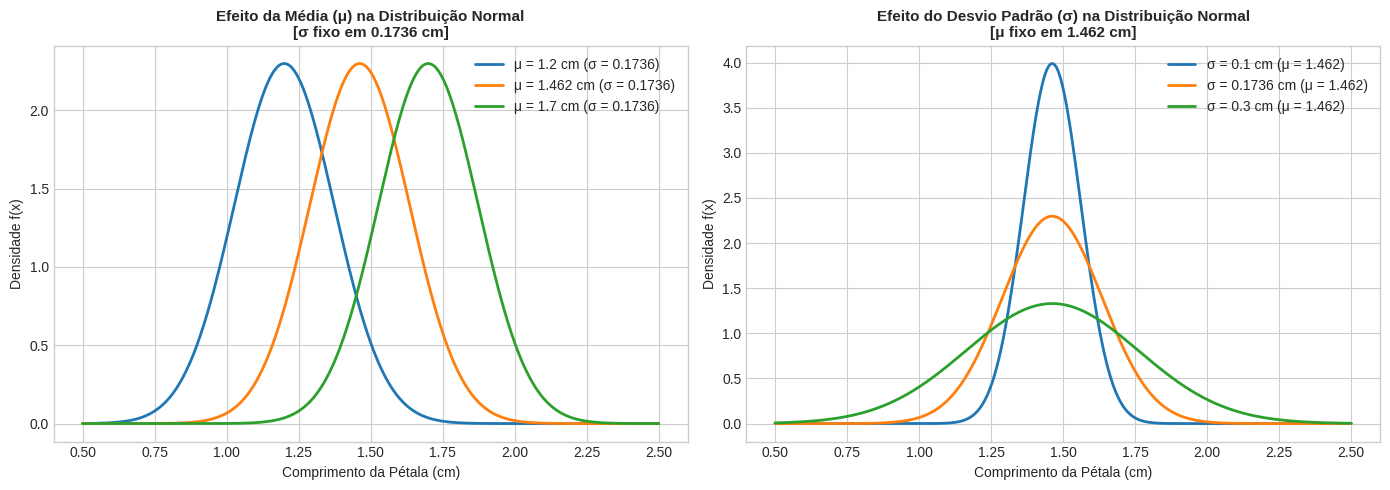

In [ ]:
# Gráficos de variação dos parâmetros mu e sigma da Distribuição Normal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_domain = np.linspace(0.5, 2.5, 500)

# 1. Variando a Média (mu) mantendo o Desvio Padrão (sigma) fixo
sigma_fixo = 0.1736
mus = [1.2, 1.462, 1.7]

for mu_val in mus:
    axes[0].plot(
        x_domain,
        stats.norm.pdf(x_domain, loc=mu_val, scale=sigma_fixo),
        lw=2,
        label=f"μ = {mu_val} cm (σ = {sigma_fixo})",
    )

axes[0].set_title(
    "Efeito da Média (μ) na Distribuição Normal\n[σ fixo em 0.1736 cm]",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_xlabel("Comprimento da Pétala (cm)")
axes[0].set_ylabel("Densidade f(x)")
axes[0].legend()

# 2. Variando o Desvio Padrão (sigma) mantendo a Média (mu) fixa
mu_fixo = 1.462
sigmas = [0.10, 0.1736, 0.30]

for sigma_val in sigmas:
    axes[1].plot(
        x_domain,
        stats.norm.pdf(x_domain, loc=mu_fixo, scale=sigma_val),
        lw=2,
        label=f"σ = {sigma_val} cm (μ = {mu_fixo})",
    )

axes[1].set_title(
    "Efeito do Desvio Padrão (σ) na Distribuição Normal\n[μ fixo em 1.462"
    " cm]",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Comprimento da Pétala (cm)")
axes[1].set_ylabel("Densidade f(x)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Probabilidades com Python — distribuição normal

### 3.1 Contextualização biológica (*Iris setosa*)

Assumindo o modelo Normal $X \sim \mathcal{N}(\mu = 1{,}462, \sigma = 0{,}1736)$ para o comprimento da pétala de *Iris setosa*, formulamos quatro perguntas biológicas:

1. **Probabilidade Acumulada ($CDF$):** Qual é a probabilidade de uma planta de *Iris setosa* escolhida ao acaso ter pétala com comprimento de **até 1,30 cm**?
2. **Probabilidade entre Dois Valores:** Qual é a probabilidade de o comprimento da pétala estar **entre 1,30 cm e 1,60 cm**?
3. **Probabilidade Acima de um Valor ($SF$):** Qual é a probabilidade de encontrar um indivíduo com pétala **maior do que 1,70 cm**?
4. **Cálculo de Percentil ($PPF$):** Qual é o comprimento limite abaixo do qual estão os **15% menores comprimentos** de pétala da espécie (15º percentil)?

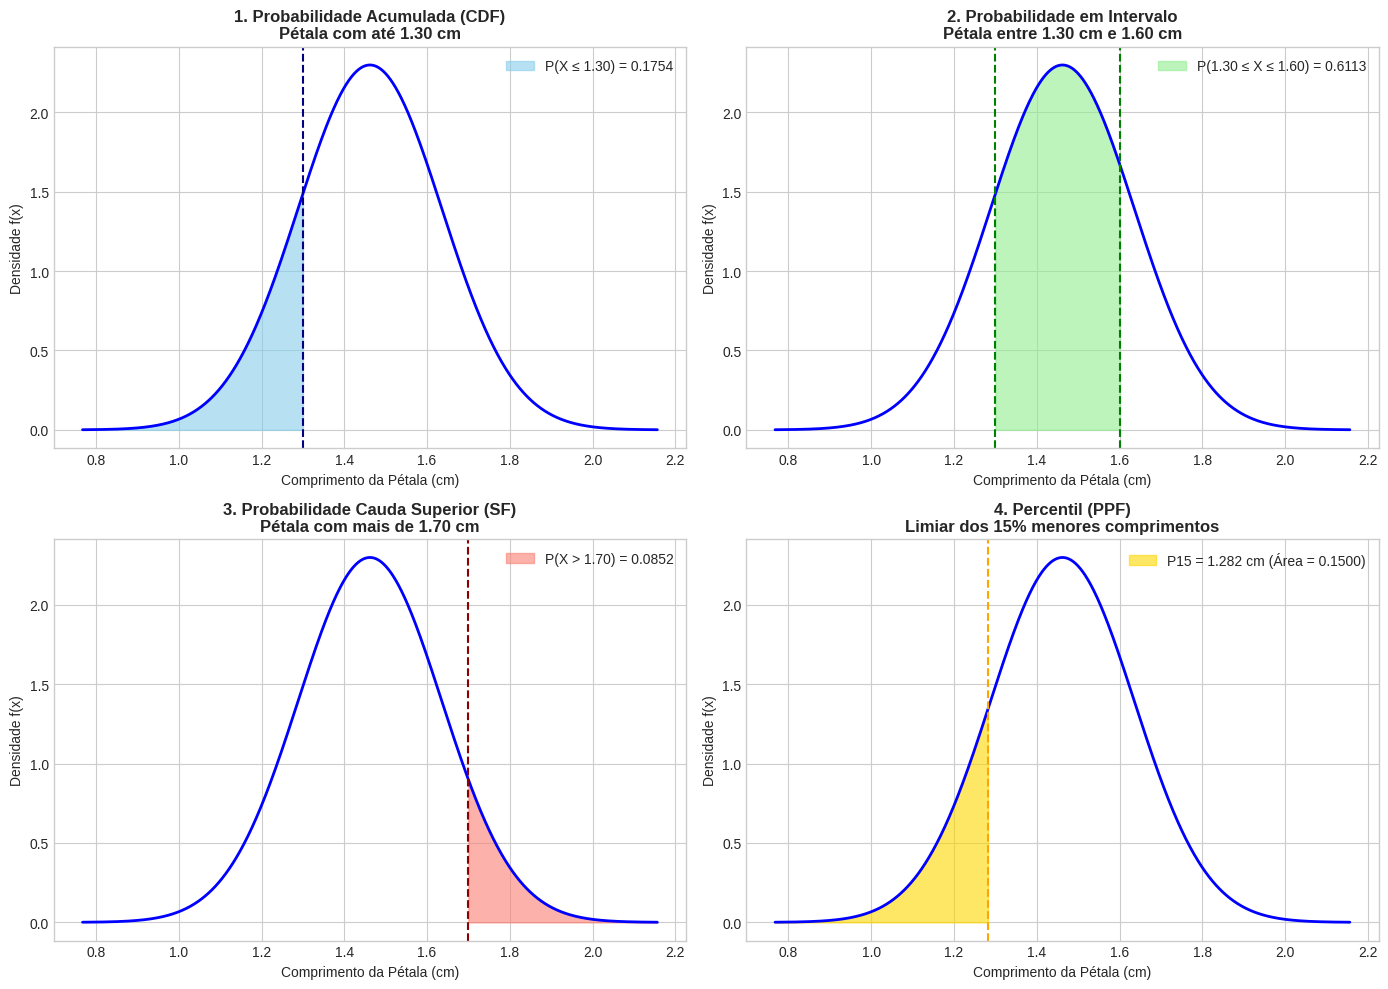

=== RESULTADOS DAS PROBABILIDADES (NORMAL) ===
1. P(X <= 1.30 cm) [CDF]  = 0.1754 (17.54%)
2. P(1.30 <= X <= 1.60 cm) = 0.6113 (61.13%)
3. P(X > 1.70 cm) [SF]   = 0.0852 (8.52%)
4. 15º Percentil [PPF]   = 1.2821 cm (15% das pétalas têm até 1.28 cm)


In [ ]:
# Cálculo das probabilidades e geração dos gráficos com área sombreada
mu = 1.462
sigma = 0.1736
dist_norm = stats.norm(loc=mu, scale=sigma)

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = dist_norm.pdf(x)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probabilidade Acumulada: P(X <= 1.30 cm)
prob_cdf = dist_norm.cdf(1.30)
axes[0, 0].plot(x, y, "b-", lw=2)
x_fill1 = np.linspace(x.min(), 1.30, 500)
axes[0, 0].fill_between(
    x_fill1,
    dist_norm.pdf(x_fill1),
    color="skyblue",
    alpha=0.6,
    label=f"P(X ≤ 1.30) = {prob_cdf:.4f}",
)
axes[0, 0].axvline(1.30, color="navy", linestyle="--")
axes[0, 0].set_title(
    "1. Probabilidade Acumulada (CDF)\nPétala com até 1.30 cm",
    fontweight="bold",
)
axes[0, 0].set_xlabel("Comprimento da Pétala (cm)")
axes[0, 0].set_ylabel("Densidade f(x)")
axes[0, 0].legend(loc="upper right")

# 2. Probabilidade em Intervalo: P(1.30 cm <= X <= 1.60 cm)
prob_int = dist_norm.cdf(1.60) - dist_norm.cdf(1.30)
axes[0, 1].plot(x, y, "b-", lw=2)
x_fill2 = np.linspace(1.30, 1.60, 500)
axes[0, 1].fill_between(
    x_fill2,
    dist_norm.pdf(x_fill2),
    color="lightgreen",
    alpha=0.6,
    label=f"P(1.30 ≤ X ≤ 1.60) = {prob_int:.4f}",
)
axes[0, 1].axvline(1.30, color="green", linestyle="--")
axes[0, 1].axvline(1.60, color="green", linestyle="--")
axes[0, 1].set_title(
    "2. Probabilidade em Intervalo\nPétala entre 1.30 cm e 1.60 cm",
    fontweight="bold",
)
axes[0, 1].set_xlabel("Comprimento da Pétala (cm)")
axes[0, 1].set_ylabel("Densidade f(x)")
axes[0, 1].legend(loc="upper right")

# 3. Probabilidade Cauda Superior: P(X > 1.70 cm)
prob_sf = dist_norm.sf(1.70)
axes[1, 0].plot(x, y, "b-", lw=2)
x_fill3 = np.linspace(1.70, x.max(), 500)
axes[1, 0].fill_between(
    x_fill3,
    dist_norm.pdf(x_fill3),
    color="salmon",
    alpha=0.6,
    label=f"P(X > 1.70) = {prob_sf:.4f}",
)
axes[1, 0].axvline(1.70, color="darkred", linestyle="--")
axes[1, 0].set_title(
    "3. Probabilidade Cauda Superior (SF)\nPétala com mais de 1.70 cm",
    fontweight="bold",
)
axes[1, 0].set_xlabel("Comprimento da Pétala (cm)")
axes[1, 0].set_ylabel("Densidade f(x)")
axes[1, 0].legend(loc="upper right")

# 4. Percentil: 15º Percentil (PPF)
p15 = dist_norm.ppf(0.15)
axes[1, 1].plot(x, y, "b-", lw=2)
x_fill4 = np.linspace(x.min(), p15, 500)
axes[1, 1].fill_between(
    x_fill4,
    dist_norm.pdf(x_fill4),
    color="gold",
    alpha=0.6,
    label=f"P15 = {p15:.3f} cm (Área = 0.1500)",
)
axes[1, 1].axvline(p15, color="orange", linestyle="--")
axes[1, 1].set_title(
    "4. Percentil (PPF)\nLimiar dos 15% menores comprimentos",
    fontweight="bold",
)
axes[1, 1].set_xlabel("Comprimento da Pétala (cm)")
axes[1, 1].set_ylabel("Densidade f(x)")
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# Exibição organizada dos valores
print("=== RESULTADOS DAS PROBABILIDADES (NORMAL) ===")
print(f"1. P(X <= 1.30 cm) [CDF]  = {prob_cdf:.4f} ({prob_cdf*100:.2f}%)")
print(
    f"2. P(1.30 <= X <= 1.60 cm) = {prob_int:.4f} ({prob_int*100:.2f}%)"
)
print(f"3. P(X > 1.70 cm) [SF]   = {prob_sf:.4f} ({prob_sf*100:.2f}%)")
print(
    f"4. 15º Percentil [PPF]   = {p15:.4f} cm (15% das pétalas têm até {p15:.2f}"
    " cm)"
)

### Discussão dos resultados

 Os cálculos de probabilidade efetuados acima representam a chance de encontrar determinados valores para uma nova medição individual em uma planta sorteada da população de *Iris setosa.
* **Concordância numérico-gráfica:**
  * $P(X \le 1{,}30) = 17{,}53\%$: A área sombreada esquerda de $1{,}30$ cm no primeiro gráfico reflete visualmente essa proporção em relação à área total de $1{,}0$ abaixo da curva.
  * $P(1{,}30 \le X \le 1{,}60) = 61{,}08\%$: Como o intervalo engloba a média ($\mu = 1{,}462$ cm), a área central verde representa a maior parte da densidade de probabilidade.
  * $P(X > 1{,}70) = 8{,}52\%$: Corresponde a um valor na cauda direita da distribuição, indicando a raridade de flores dessa espécie com pétalas tão grandes.
  * 15º Percentil ($1{,}282$ cm): Confirma que $15\%$ da área total da distribuição está contida do extremo esquerdo até o valor limite de $1{,}282$ cm.


## 4. Distribuição t de Student

### 4.1 Fundamentação teórica

A distribuição t de Student é utilizada para estudar uma estatística associada à média amostral quando a variância populacional é desconhecida e estimada a partir dos próprios dados. Considerando uma amostra aleatória independente de uma população Normal, a estatística é definida por:

$$T=\frac{\overline{X}-\mu_0}{S/\sqrt{n}} \sim t_{\nu}, \qquad \nu=n-1$$

Sob a hipótese de que a média populacional é igual ao valor de referência ($H_0:\mu=\mu_0$), sua função densidade é:

$$f(t;\nu)=\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)}\left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

**Definição dos símbolos:**

- $T$: estatística t padronizada, sem unidade.
- $\overline{X}$: média amostral do comprimento das pétalas (cm).
- $\mu_0$: média populacional estabelecida como referência (cm).
- $S$: desvio padrão amostral (cm).
- $n$: número de observações da amostra.
- $\nu$: graus de liberdade ($n-1$).
- $t$: valor assumido pela estatística, podendo variar de $-\infty$ a $+\infty$.
- $\Gamma$: função gama, uma generalização da função fatorial.
- $\pi$: constante matemática aproximadamente igual a 3,14159.

O parâmetro $\nu$ deve ser positivo. Na aplicação com a variância estimada a partir de uma amostra, $n\geq2$ e $\nu=n-1$.

### 4.2 Interpretação biológica e efeito dos parâmetros

Neste trabalho, a distribuição t de Student é aplicada à média amostral do comprimento das pétalas de *Iris setosa*. A medida individual de uma pétala é expressa em centímetros, enquanto a estatística t representa o afastamento da média amostral em relação a uma referência, medido em unidades de erro padrão.

O parâmetro da distribuição t padrão é o número de graus de liberdade ($\nu$).

- **Poucos graus de liberdade:** a curva apresenta caudas mais pesadas e menor concentração de densidade próxima ao centro.
- **Muitos graus de liberdade:** as caudas tornam-se mais leves e a curva se aproxima da distribuição Normal padrão.
- **Posição e simetria:** a distribuição permanece simétrica e centrada em zero, independentemente dos graus de liberdade.

A distribuição t padrão não apresenta parâmetros de média e desvio padrão livremente ajustáveis como a distribuição Normal geral. Sua forma é controlada pelos graus de liberdade.

### 4.3 Condições de aplicação e limitações

A distribuição t exata pressupõe observações aleatórias e independentes provenientes de uma população Normal. Como a base Iris contém observações históricas e não garante representatividade de todas as populações naturais da espécie, os resultados devem ser interpretados com cautela.

**Pergunta biológica:** considerando hipoteticamente que a média populacional do comprimento das pétalas de *Iris setosa* seja 1,50 cm, quão incomum seria a média observada nas 50 flores?

O valor de 1,50 cm é uma referência didática, não um parâmetro populacional comprovado.


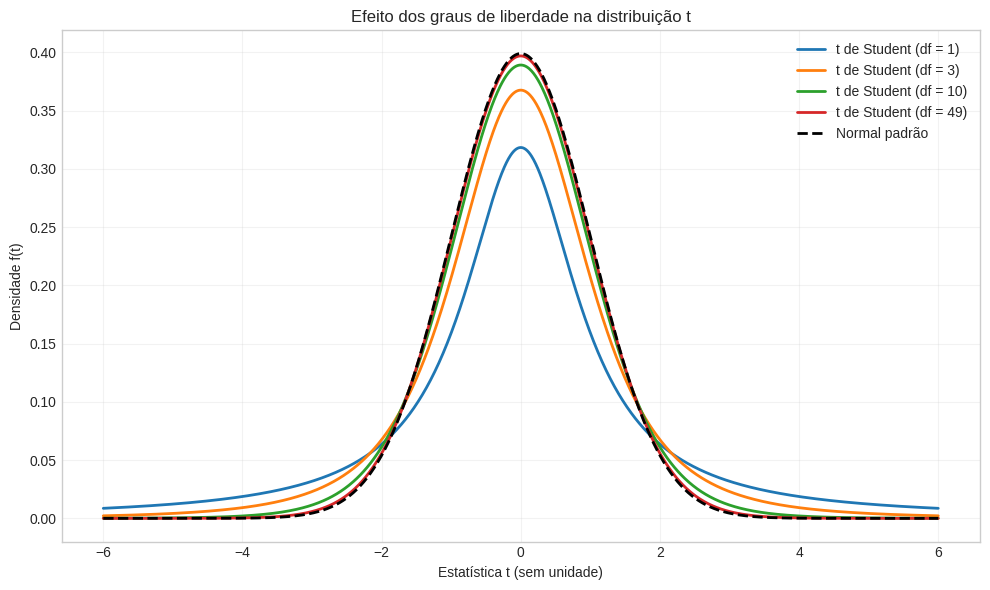

In [ ]:

# Gráfico de variação dos graus de liberdade da t de Student

x_t = np.linspace(-6, 6, 1200)

plt.figure(figsize=(10, 6))

for gl in [1, 3, 10, 49]:
    plt.plot(
        x_t,
        stats.t.pdf(x_t, df=gl),
        linewidth=2,
        label=f"t de Student (df = {gl})"
    )

plt.plot(
    x_t,
    stats.norm.pdf(x_t),
    "k--",
    linewidth=2,
    label="Normal padrão"
)

plt.title("Efeito dos graus de liberdade na distribuição t")
plt.xlabel("Estatística t (sem unidade)")
plt.ylabel("Densidade f(t)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



### 4.4 Probabilidades com Python

Considerando a hipótese $H_0:\mu=1{,}50$ cm, a estatística $T=(\overline{X}-1{,}50)/(S/\sqrt{50})$ segue uma distribuição t com 49 graus de liberdade, desde que os pressupostos sejam atendidos.

As probabilidades representam a variação esperada da estatística amostral em repetidas amostragens hipotéticas sob essa hipótese, e não a probabilidade de uma pétala individual apresentar determinado comprimento.

1. **Probabilidade acumulada (CDF):** qual é a probabilidade de a média padronizada apresentar $T\leq-1$?
2. **Probabilidade entre dois valores:** qual é a probabilidade de a estatística estar entre $-2$ e $0$?
3. **Cauda superior (SF):** qual é a probabilidade de a estatística superar $1{,}5$?
4. **Percentil (PPF):** qual valor de t delimita os 95% inferiores da distribuição?

Os limites representam afastamentos padronizados da média de referência. Para relacioná-los à escala biológica, utilizamos $\overline{x}=\mu_0+t\,s/\sqrt{n}$, fixando o erro padrão observado apenas para fins ilustrativos. Em novas amostras, o desvio padrão também pode variar.


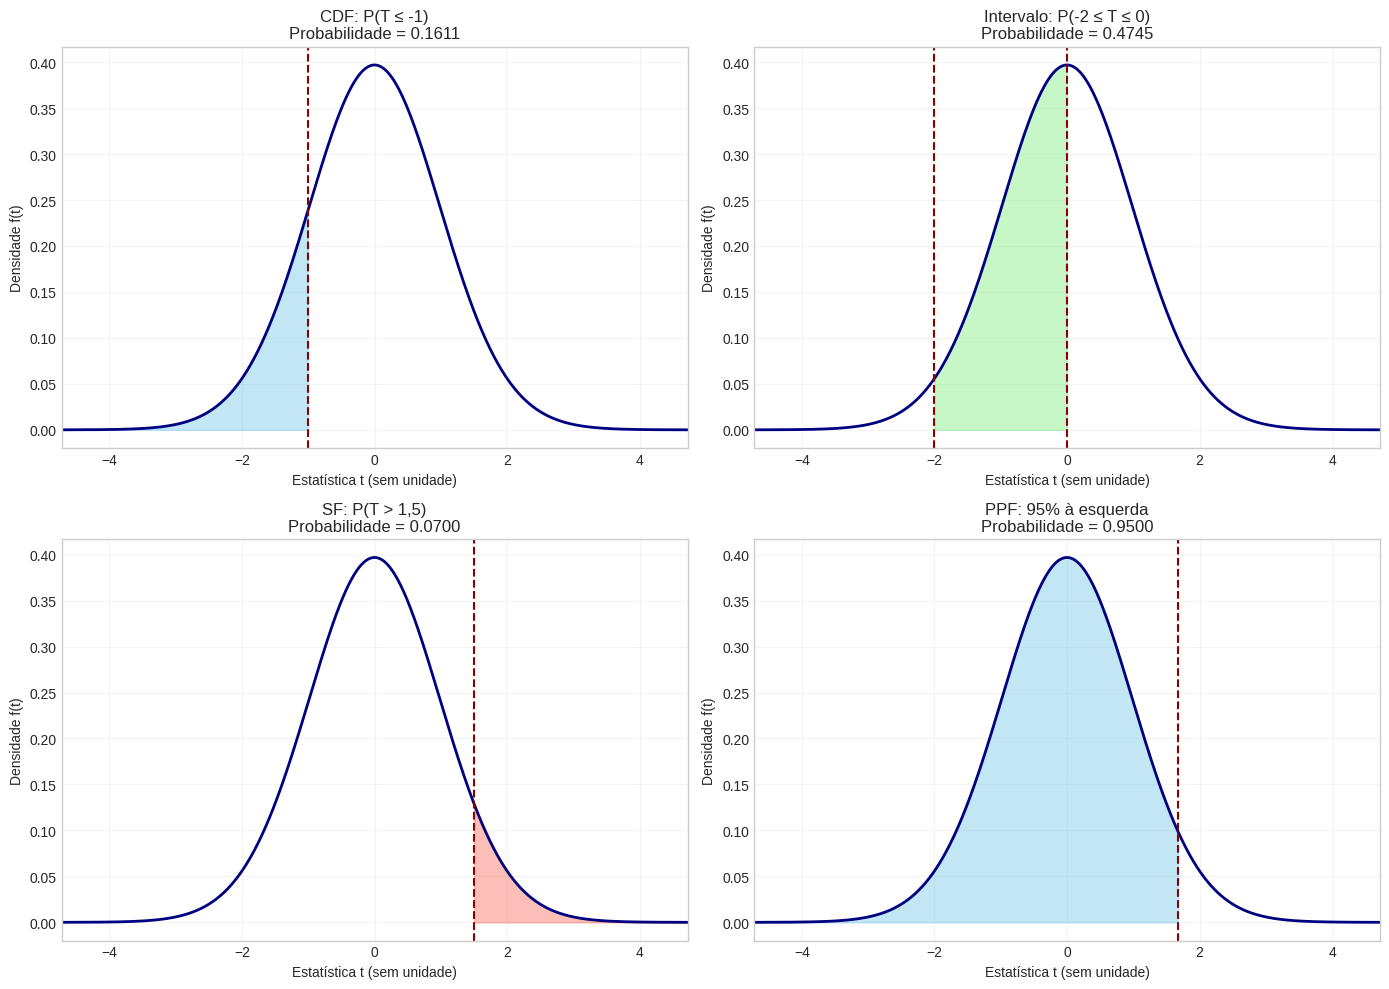

=== DISTRIBUIÇÃO t DE STUDENT ===
Amostra: 50 flores
Média observada: 1.4640 cm
Desvio padrão: 0.1735 cm
Erro padrão: 0.0245 cm
Graus de liberdade: 49

CDF: 0.161112
Intervalo: 0.474470
SF: 0.070015
Percentil 95: t = 1.6766

t observado: -1.4671
Valor-p bilateral: 0.148738

Conversão aproximada para centímetros:
t = -2.0000: 1.4509 cm
t = -1.0000: 1.4755 cm
t = 0.0000: 1.5000 cm
t = 1.5000: 1.5368 cm
t = 1.6766: 1.5411 cm


In [ ]:

# Dados previamente carregados pelo Membro 1
# Utiliza setosa_petal_length e as bibliotecas já importadas

amostra_t = setosa_petal_length.dropna()
n = len(amostra_t)
media = amostra_t.mean()
s = amostra_t.std(ddof=1)
s2 = amostra_t.var(ddof=1)
se = s / np.sqrt(n)
df_amostral = n - 1

mu0 = 1.50  # Referência hipotética (cm)

t_obs = (media - mu0) / se
dist_t = stats.t(df=df_amostral)

t95 = dist_t.ppf(0.95)

# Cálculo das probabilidades
prob_cdf_t = dist_t.cdf(-1)
prob_int_t = dist_t.cdf(0) - dist_t.cdf(-2)
prob_sf_t = dist_t.sf(1.5)
prob_ppf_t = dist_t.cdf(t95)

# Gráficos com áreas sombreadas
x_t = np.linspace(
    dist_t.ppf(0.00001),
    dist_t.ppf(0.99999),
    1500
)

casos_t = [
    ("CDF: P(T ≤ -1)", None, -1, prob_cdf_t),
    ("Intervalo: P(-2 ≤ T ≤ 0)", -2, 0, prob_int_t),
    ("SF: P(T > 1,5)", 1.5, None, prob_sf_t),
    ("PPF: 95% à esquerda", None, t95, prob_ppf_t)
]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, (titulo, a, b, prob) in zip(axs.flat, casos_t):
    ax.plot(x_t, dist_t.pdf(x_t), color="navy", lw=2)

    if a is None:
        ax.fill_between(
            x_t, dist_t.pdf(x_t),
            where=(x_t <= b),
            color="skyblue", alpha=0.5
        )
        ax.axvline(b, color="darkred", linestyle="--")

    elif b is None:
        ax.fill_between(
            x_t, dist_t.pdf(x_t),
            where=(x_t >= a),
            color="salmon", alpha=0.5
        )
        ax.axvline(a, color="darkred", linestyle="--")

    else:
        ax.fill_between(
            x_t, dist_t.pdf(x_t),
            where=(x_t >= a) & (x_t <= b),
            color="lightgreen", alpha=0.5
        )
        ax.axvline(a, color="darkred", linestyle="--")
        ax.axvline(b, color="darkred", linestyle="--")

    ax.set_title(f"{titulo}\nProbabilidade = {prob:.4f}")
    ax.set_xlabel("Estatística t (sem unidade)")
    ax.set_ylabel("Densidade f(t)")
    ax.set_xlim(x_t.min(), x_t.max())
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("=== DISTRIBUIÇÃO t DE STUDENT ===")
print(f"Amostra: {n} flores")
print(f"Média observada: {media:.4f} cm")
print(f"Desvio padrão: {s:.4f} cm")
print(f"Erro padrão: {se:.4f} cm")
print(f"Graus de liberdade: {df_amostral}")

print(f"\nCDF: {prob_cdf_t:.6f}")
print(f"Intervalo: {prob_int_t:.6f}")
print(f"SF: {prob_sf_t:.6f}")
print(f"Percentil 95: t = {t95:.4f}")

print(f"\nt observado: {t_obs:.4f}")
print(f"Valor-p bilateral: {2 * dist_t.sf(abs(t_obs)):.6f}")

print("\nConversão aproximada para centímetros:")
for limite in [-2, -1, 0, 1.5, t95]:
    equivalente = mu0 + limite * se
    print(f"t = {limite:.4f}: {equivalente:.4f} cm")



### 4.5 Discussão dos resultados

A distribuição t de Student permite estudar a variação da média amostral padronizada do comprimento das pétalas de *Iris setosa*, considerando uma média populacional hipotética de 1,50 cm.

A probabilidade acumulada representa a área à esquerda de $t=-1$. A probabilidade em intervalo corresponde à região entre $t=-2$ e $t=0$, enquanto a cauda superior representa os valores maiores que $t=1{,}5$. O percentil 95 delimita o valor abaixo do qual se encontram 95% dos resultados possíveis sob o modelo.

As áreas sombreadas concordam aproximadamente com as probabilidades numéricas. As pequenas diferenças visuais decorrem do recorte finito dos eixos e da resolução dos gráficos.

A estatística observada relaciona a média das 50 flores à referência de 1,50 cm, considerando o erro padrão estimado. O valor-p bilateral representa a probabilidade, sob a hipótese nula e os pressupostos da distribuição t, de obter uma estatística com magnitude pelo menos tão extrema quanto a observada.

Como a média de referência foi escolhida para fins didáticos, esse resultado não constitui, isoladamente, evidência de uma hipótese biológica estabelecida previamente. Além disso, a amostragem histórica da base Iris limita a generalização dos resultados.



## 5. Distribuição Qui-Quadrado ($\chi^2$)

### 5.1 Fundamentação teórica

A distribuição Qui-Quadrado é uma distribuição contínua utilizada, entre outras aplicações, para estudar a variabilidade de uma população por meio de uma estatística construída a partir da variância amostral.

Se uma amostra aleatória independente de tamanho $n$ é retirada de uma população Normal, sob a hipótese $H_0:\sigma^2=\sigma_0^2$, temos:

$$Q=\frac{(n-1)S^2}{\sigma_0^2}\sim\chi^2_k,\qquad k=n-1$$

A função densidade da distribuição Qui-Quadrado é:

$$f(q;k)=\frac{1}{2^{k/2}\Gamma(k/2)}q^{k/2-1}e^{-q/2},\qquad q>0,\ k>0$$

**Definição dos símbolos:**

- $Q$: estatística Qui-Quadrado, sem unidade.
- $q$: valor assumido pela estatística, sendo $q\geq0$.
- $n$: tamanho da amostra.
- $S^2$: variância amostral do comprimento das pétalas, expressa em cm².
- $\sigma_0^2$: variância populacional de referência, expressa em cm².
- $k$: graus de liberdade, calculados por $n-1$.
- $\Gamma$: função gama, generalização da função fatorial.
- $e$: base do logaritmo natural, aproximadamente 2,71828.
- $f(q;k)$: função densidade de probabilidade.

O parâmetro $k$ deve ser positivo. Na aplicação à variância amostral, $k=n-1$ é um número inteiro positivo.

A distribuição Qui-Quadrado também pode ser definida como a distribuição da soma dos quadrados de $k$ variáveis aleatórias independentes com distribuição Normal padrão.

### 5.2 Interpretação biológica e efeito dos parâmetros

Neste trabalho, a distribuição Qui-Quadrado representa uma estatística associada à variância amostral do comprimento das pétalas de *Iris setosa*.

A variância observada é uma medida de dispersão expressa em cm², enquanto a estatística Qui-Quadrado é uma quantidade padronizada e sem unidade. Portanto, a distribuição não descreve diretamente o comprimento individual das pétalas.

O único parâmetro da distribuição é o número de graus de liberdade ($k$).

- **Valores pequenos de k:** a distribuição apresenta forte assimetria à direita e cauda relativamente longa.
- **Valores elevados de k:** a distribuição desloca-se para valores maiores e apresenta menor assimetria relativa, aproximando-se de uma forma mais simétrica.
- **Dispersão:** a média da distribuição é $k$ e sua variância é $2k$. Portanto, sua dispersão absoluta aumenta com $k$, embora a dispersão relativa diminua.
- **Caudas:** a cauda direita é especialmente evidente para poucos graus de liberdade.

### 5.3 Condições de aplicação e limitações

A distribuição exata da estatística associada à variância exige observações aleatórias, independentes e provenientes de uma população Normal.

A distribuição Qui-Quadrado é especialmente sensível a desvios da Normalidade, de modo que os resultados devem ser interpretados condicionalmente a esses pressupostos.

**Pergunta biológica:** considerando hipoteticamente que a variância populacional do comprimento das pétalas de *Iris setosa* seja 0,0400 cm², quão incomum seria a variância observada nas 50 flores?

O valor 0,0400 cm² corresponde a um desvio padrão populacional de 0,20 cm e foi escolhido apenas como referência didática, não sendo uma estimativa externa comprovada.


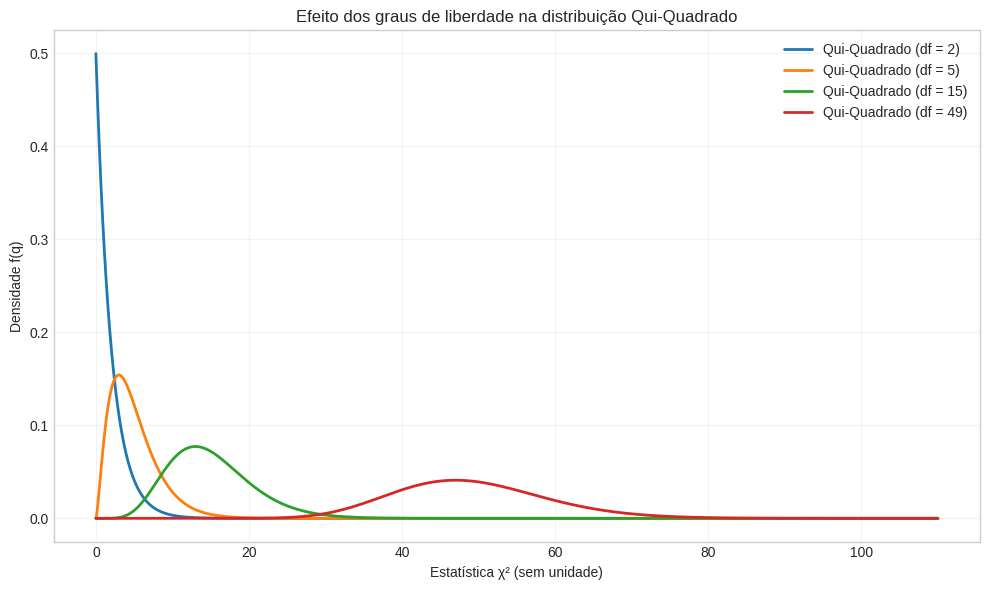

In [ ]:

# Gráfico de variação dos graus de liberdade da Qui-Quadrado

x_chi = np.linspace(0.001, 110, 1500)

plt.figure(figsize=(10, 6))

for gl in [2, 5, 15, 49]:
    plt.plot(
        x_chi,
        stats.chi2.pdf(x_chi, df=gl),
        linewidth=2,
        label=f"Qui-Quadrado (df = {gl})"
    )

plt.title("Efeito dos graus de liberdade na distribuição Qui-Quadrado")
plt.xlabel("Estatística χ² (sem unidade)")
plt.ylabel("Densidade f(q)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



### 5.4 Probabilidades com Python

Considerando a hipótese de que a variância populacional do comprimento das pétalas de *Iris setosa* seja igual a 0,0400 cm², a estatística $Q=49S^2/0{,}0400$ segue uma distribuição Qui-Quadrado com 49 graus de liberdade, desde que os pressupostos sejam atendidos.

As probabilidades representam possíveis valores da estatística calculada a partir de novas amostras hipotéticas, e não probabilidades associadas diretamente a comprimentos individuais de pétalas.

1. **Probabilidade acumulada (CDF):** qual é a probabilidade de obter $Q\leq40$?
2. **Probabilidade entre dois valores:** qual é a probabilidade de obter $35\leq Q\leq65$?
3. **Cauda superior (SF):** qual é a probabilidade de obter $Q>70$?
4. **Percentil (PPF):** qual é o limite abaixo do qual se encontram 95% dos valores da estatística?

Os limites escolhidos representam diferentes níveis de variabilidade amostral em relação à variância de referência.

Para interpretar esses valores na escala biológica original, utiliza-se:

$$S^2=\frac{Q\sigma_0^2}{n-1}$$

Dessa forma, os limites da estatística Qui-Quadrado podem ser convertidos em valores de variância amostral expressos em cm².


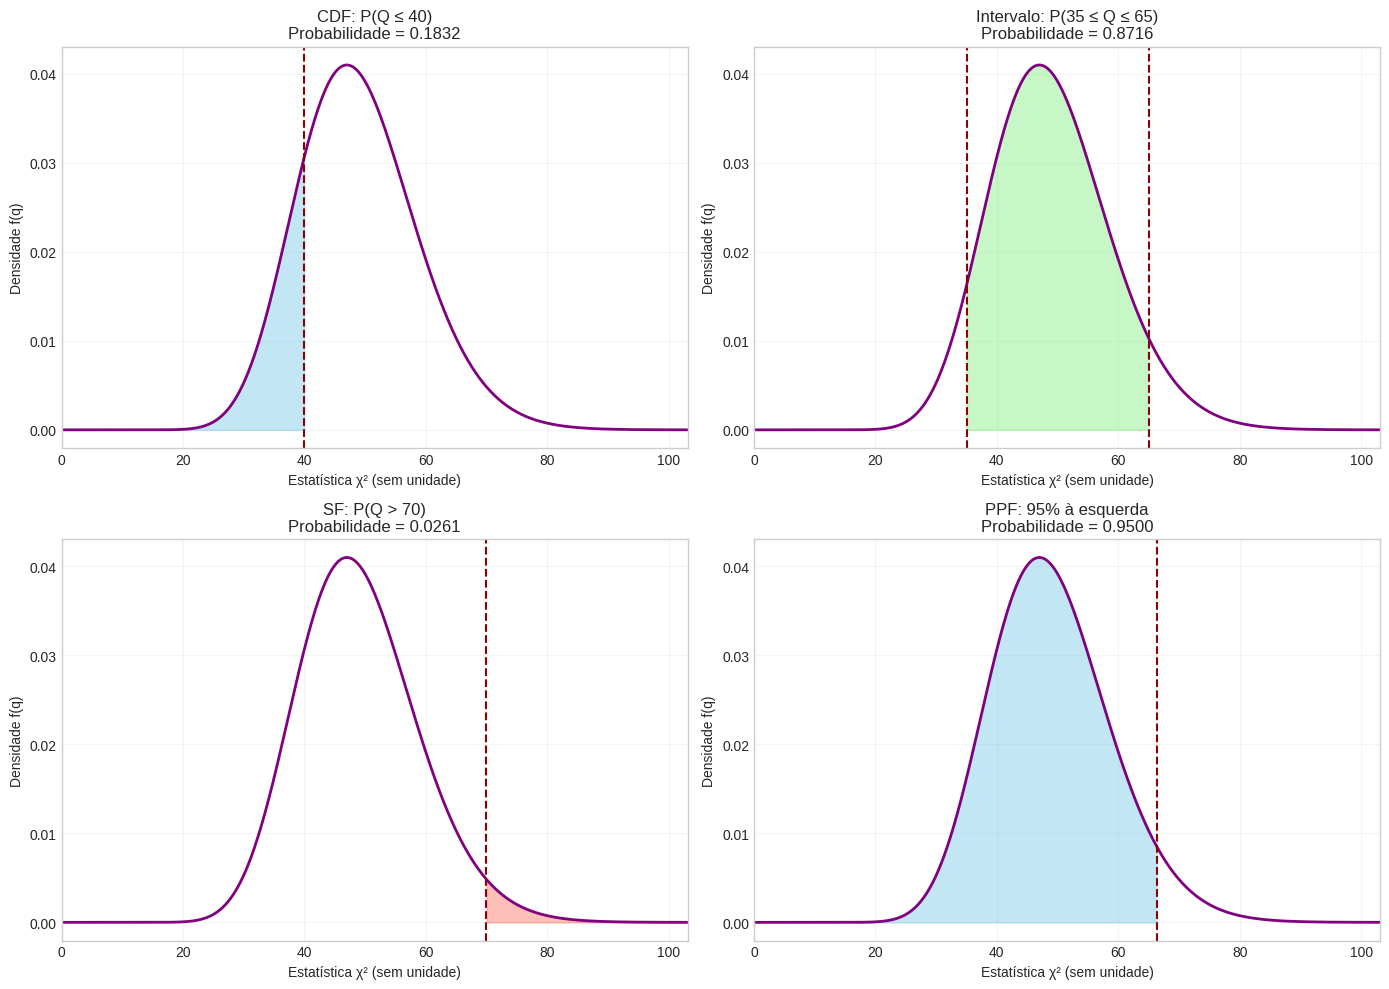

=== DISTRIBUIÇÃO QUI-QUADRADO ===
Variância observada: 0.030106 cm²
Variância de referência: 0.040000 cm²
Graus de liberdade: 49

CDF: 0.183223
Intervalo: 0.871630
SF: 0.026055
Percentil 95: Q = 66.3386

Qui-Quadrado observado: 36.8800
Valor-p bilateral: 0.202665

Conversão dos limites para cm²:
Q = 35.0000: 0.028571 cm²
Q = 40.0000: 0.032653 cm²
Q = 65.0000: 0.053061 cm²
Q = 70.0000: 0.057143 cm²
Q = 66.3386: 0.054154 cm²


In [ ]:

# Distribuição Qui-Quadrado aplicada à variância amostral

sigma0 = 0.20  # Referência hipotética (cm)
var0 = sigma0 ** 2

# Estatísticas calculadas a partir dos dados reais
amostra_chi = setosa_petal_length.dropna()
n_chi = len(amostra_chi)
gl_chi = n_chi - 1
s2_chi = amostra_chi.var(ddof=1)

q_obs = gl_chi * s2_chi / var0

dist_chi = stats.chi2(df=gl_chi)
q95 = dist_chi.ppf(0.95)

# Probabilidades
prob_cdf_chi = dist_chi.cdf(40)
prob_int_chi = dist_chi.cdf(65) - dist_chi.cdf(35)
prob_sf_chi = dist_chi.sf(70)
prob_ppf_chi = dist_chi.cdf(q95)

x_chi = np.linspace(
    0,
    dist_chi.ppf(0.99999),
    1500
)

casos_chi = [
    ("CDF: P(Q ≤ 40)", None, 40, prob_cdf_chi),
    ("Intervalo: P(35 ≤ Q ≤ 65)", 35, 65, prob_int_chi),
    ("SF: P(Q > 70)", 70, None, prob_sf_chi),
    ("PPF: 95% à esquerda", None, q95, prob_ppf_chi)
]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, (titulo, a, b, prob) in zip(axs.flat, casos_chi):
    ax.plot(x_chi, dist_chi.pdf(x_chi), color="purple", lw=2)

    if a is None:
        ax.fill_between(
            x_chi, dist_chi.pdf(x_chi),
            where=(x_chi <= b),
            color="skyblue", alpha=0.5
        )
        ax.axvline(b, color="darkred", linestyle="--")

    elif b is None:
        ax.fill_between(
            x_chi, dist_chi.pdf(x_chi),
            where=(x_chi >= a),
            color="salmon", alpha=0.5
        )
        ax.axvline(a, color="darkred", linestyle="--")

    else:
        ax.fill_between(
            x_chi, dist_chi.pdf(x_chi),
            where=(x_chi >= a) & (x_chi <= b),
            color="lightgreen", alpha=0.5
        )
        ax.axvline(a, color="darkred", linestyle="--")
        ax.axvline(b, color="darkred", linestyle="--")

    ax.set_title(f"{titulo}\nProbabilidade = {prob:.4f}")
    ax.set_xlabel("Estatística χ² (sem unidade)")
    ax.set_ylabel("Densidade f(q)")
    ax.set_xlim(x_chi.min(), x_chi.max())
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("=== DISTRIBUIÇÃO QUI-QUADRADO ===")
print(f"Variância observada: {s2_chi:.6f} cm²")
print(f"Variância de referência: {var0:.6f} cm²")
print(f"Graus de liberdade: {gl_chi}")

print(f"\nCDF: {prob_cdf_chi:.6f}")
print(f"Intervalo: {prob_int_chi:.6f}")
print(f"SF: {prob_sf_chi:.6f}")
print(f"Percentil 95: Q = {q95:.4f}")

p_bilateral_chi = min(
    1.0,
    2 * min(dist_chi.cdf(q_obs), dist_chi.sf(q_obs))
)

print(f"\nQui-Quadrado observado: {q_obs:.4f}")
print(f"Valor-p bilateral: {p_bilateral_chi:.6f}")

print("\nConversão dos limites para cm²:")
for limite in [35, 40, 65, 70, q95]:
    equivalente = limite * var0 / gl_chi
    print(f"Q = {limite:.4f}: {equivalente:.6f} cm²")



### 5.5 Discussão dos resultados

A distribuição Qui-Quadrado permite avaliar a variabilidade amostral do comprimento das pétalas de *Iris setosa*, considerando uma variância populacional hipotética de 0,0400 cm².

A probabilidade acumulada representa a área à esquerda de $Q=40$. A probabilidade em intervalo corresponde à região entre $Q=35$ e $Q=65$, enquanto a cauda superior representa valores maiores que $Q=70$. O percentil 95 indica o limite abaixo do qual estão 95% dos valores possíveis da estatística sob o modelo.

As áreas sombreadas correspondem aproximadamente às probabilidades calculadas. Pequenas diferenças visuais podem ocorrer porque os gráficos representam apenas uma faixa finita da distribuição.

A estatística Qui-Quadrado observada compara a variância das 50 flores com a variância hipotética de 0,0400 cm². O valor-p bilateral quantifica o grau de incompatibilidade entre a estatística observada e a hipótese de referência, considerando o modelo e seus pressupostos.

Como a variância de referência foi escolhida para fins didáticos, o resultado não representa a confirmação de uma hipótese biológica estabelecida previamente.

A validade exata dessa análise depende especialmente da Normalidade e da independência das observações. Para comparar diretamente a variabilidade das pétalas de *Iris setosa* e *Iris versicolor*, a distribuição F de Fisher é mais apropriada, sendo apresentada na seção seguinte.

### 5.6 Síntese das distribuições t e Qui-Quadrado

A distribuição t de Student representa a variação de uma estatística associada à média amostral, enquanto a distribuição Qui-Quadrado representa a variação de uma estatística associada à variância amostral.

Ambas são construídas a partir de observações biológicas reais, mas suas curvas não representam diretamente a distribuição dos comprimentos individuais das pétalas. As probabilidades calculadas são condicionais às hipóteses estatísticas estabelecidas e às limitações da base de dados.


## 6. Distribuição F de Fisher (Snedecor)

### 6.1 Fundamentação teórica

A distribuição F de Snedecor (ou F de Fisher) é uma distribuição de probabilidade contínua que surge naturalmente como a distribuição da razão de duas variâncias amostrais independentes provenientes de populações normais.

#### **1. Função densidade de probabilidade**

Se $X$ é uma variável aleatória contínua com distribuição F, sua função densidade de probabilidade é dada por:

$$f(x) = \frac{\Gamma\left(\frac{d_1 + d_2}{2}\right)}{\Gamma\left(\frac{d_1}{2}\right) \Gamma\left(\frac{d_2}{2}\right)} \left(\frac{d_1}{d_2}\right)^{\frac{d_1}{2}} x^{\frac{d_1}{2} - 1} \left(1 + \frac{d_1}{d_2}x\right)^{-\frac{d_1 + d_2}{2}}, \quad \text{para } x > 0$$

**Definição dos símbolos:**
* $x$: O valor assumido pela variável (a razão entre as variâncias).
* $d_1$: Graus de liberdade do numerador ($df_1$).
* $d_2$: Graus de liberdade do denominador ($df_2$).
* $\Gamma$: Função Gama, uma generalização do fatorial para números reais.

*Fonte teórica consultada:* BUSSAB, Wilton de O.; MORETTIN, Pedro A. **Estatística Básica**. 9. ed. São Paulo: Saraiva, 2017.

#### **2. Explicação da razão de variâncias e parâmetros**

Sejam $S_1^2$ e $S_2^2$ as variâncias amostrais calculadas a partir de duas amostras independentes de tamanhos $n_1$ e $n_2$, extraídas de duas populações normais com variâncias populacionais $\sigma_1^2$ e $\sigma_2^2$.
Sob a hipótese nula de igualdade de variâncias populacionais ($\sigma_1^2 = \sigma_2^2$):

$$F = \frac{S_1^2}{S_2^2} \sim F(d_1 = n_1 - 1, \, d_2 = n_2 - 1)$$

* **$df_1$ (Graus de liberdade do numerador):** Está associado ao tamanho amostral do grupo que está no numerador ($n_1 - 1$). Ele determina o comportamento inicial da curva próximo à origem e a velocidade de decaimento.
* **$df_2$ (Graus de liberdade do denominador):** Está associado ao tamanho amostral do grupo no denominador ($n_2 - 1$). Controla a estabilidade da cauda direita da distribuição (pesos extremos).

#### **3. Condições de aplicação**

1. As amostras de ambos os grupos devem ser extraídas de populações que seguem aproximadamente uma **distribuição Normal**.
2. As duas amostras devem ser **independentes** entre si.

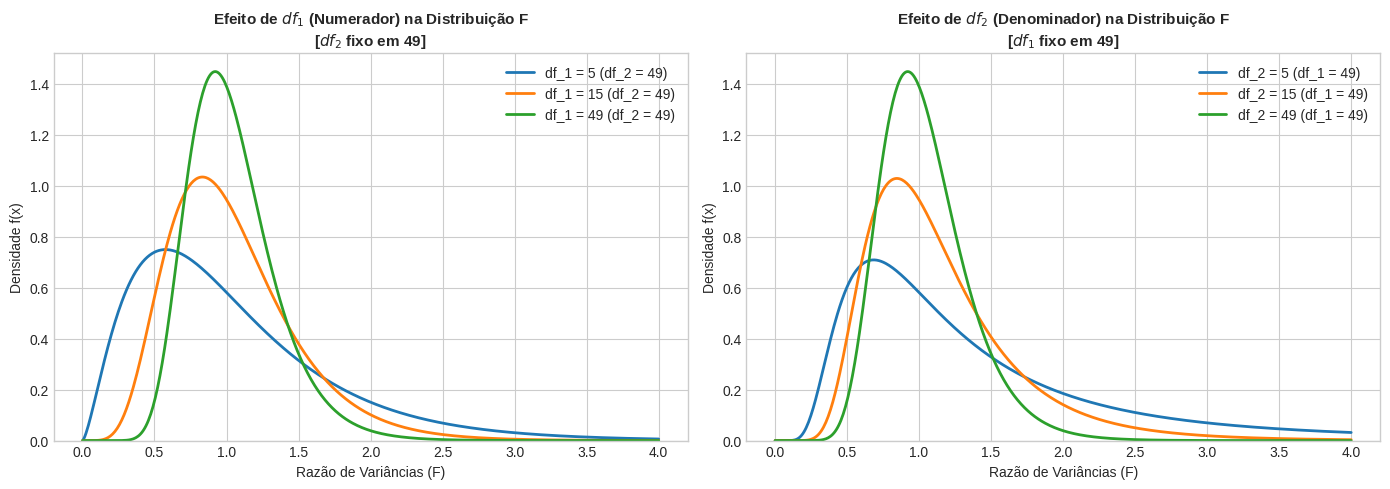

In [ ]:
# Gráficos de variação dos parâmetros df_1 e df_2 da Distribuição F de Fisher
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_f = np.linspace(0.001, 4.0, 500)

# 1. Variando df_1 (numerador) mantendo df_2 fixo
df2_fixo = 49
df1_valores = [5, 15, 49]

for df1_val in df1_valores:
    axes[0].plot(
        x_f,
        stats.f.pdf(x_f, dfn=df1_val, dfd=df2_fixo),
        lw=2,
        label=f"df_1 = {df1_val} (df_2 = {df2_fixo})",
    )

axes[0].set_title(
    "Efeito de $df_1$ (Numerador) na Distribuição F\n[$df_2$ fixo em 49]",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_xlabel("Razão de Variâncias (F)")
axes[0].set_ylabel("Densidade f(x)")
axes[0].legend()
axes[0].set_ylim(bottom=0)

# 2. Variando df_2 (denominador) mantendo df_1 fixo
df1_fixo = 49
df2_valores = [5, 15, 49]

for df2_val in df2_valores:
    axes[1].plot(
        x_f,
        stats.f.pdf(x_f, dfn=df1_fixo, dfd=df2_val),
        lw=2,
        label=f"df_2 = {df2_val} (df_1 = {df1_fixo})",
    )

axes[1].set_title(
    "Efeito de $df_2$ (Denominador) na Distribuição F\n[$df_1$ fixo em 49]",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Razão de Variâncias (F)")
axes[1].set_ylabel("Densidade f(x)")
axes[1].legend()
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### 6.2 Contextualização biológica e formulação de perguntas (F de Fisher)

Anteriormente, calculamos a variância amostral para as pétalas das duas espécies:
* **$S^2_{\text{versicolor}} \approx 0{,}2208 \text{ cm}^2$** ($n_2 = 50$, logo $df_2 = 49$)
* **$S^2_{\text{setosa}} \approx 0{,}0301 \text{ cm}^2$** ($n_1 = 50$, logo $df_1 = 49$)

Supondo que as populações de ambas as espécies possuam, sob a hipótese nula de equivalência biológica, a mesma variabilidade real, o quociente entre as variâncias amostrais segue o modelo **$F \sim F(d_1 = 49, \, d_2 = 49)$**.

A razão calculada a partir de nossos dados amostrais reais é:
$$F_{\text{calculado}} = \frac{S^2_{\text{versicolor}}}{S^2_{\text{setosa}}} = \frac{0{,}220816}{0{,}030106} \approx 7{,}334$$

Formulamos quatro perguntas sobre esse modelo probabilístico:
1. **Probabilidade Acumulada ($CDF$):** Qual é a probabilidade de obtermos uma razão de variâncias de **até 1,50**?
2. **Probabilidade entre Dois Valores:** Qual é a probabilidade de a razão de variâncias estar **entre 0,80 e 1,20** (valores muito próximos da igualdade)?
3. **Probabilidade Acima de um Valor ($SF$):** Qual é a probabilidade de encontrar, ao acaso, uma razão de variâncias **maior ou igual a 1,80**?
4. **Cálculo de Percentil ($PPF$):** Qual é o valor limite de $F$ abaixo do qual estão contidos os **95% menores valores** sob a hipótese nula (95º percentil para teste unilateral)?

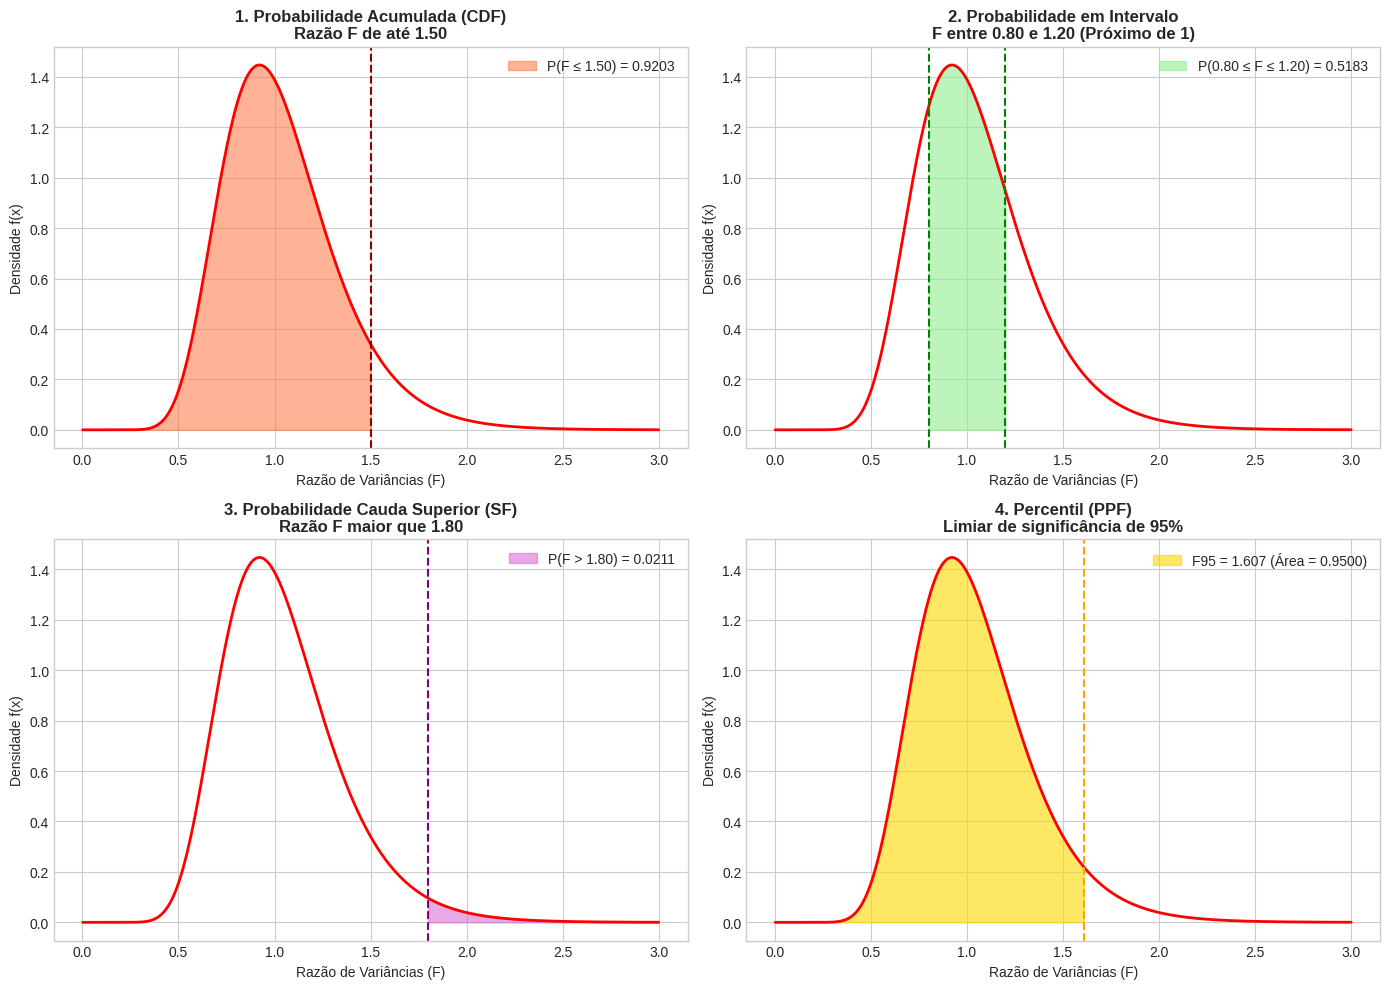

=== RESULTADOS DAS PROBABILIDADES (DISTRIBUIÇÃO F) ===
1. P(F <= 1.50) [CDF]       = 0.9203 (92.03%)
2. P(0.80 <= F <= 1.20)     = 0.5183 (51.83%)
3. P(F > 1.80) [SF]         = 0.0211 (2.11%)
4. 95º Percentil [PPF]      = 1.6073 (95% das razões de variância vão até 1.61)

Razão F Realmente Observada (Versicolor/Setosa) = 7.3346
Probabilidade (P-valor unilateral) de encontrar valor tão extremo sob H0 = 4.96e-11


In [ ]:
# Definição dos graus de liberdade baseados no dataset real (n=50 para cada)
df1 = 49
df2 = 49
dist_f = stats.f(dfn=df1, dfd=df2)

x_f_grid = np.linspace(0.001, 3.0, 1000)
y_f_grid = dist_f.pdf(x_f_grid)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probabilidade Acumulada: P(F <= 1.50)
prob_cdf_f = dist_f.cdf(1.50)
axes[0, 0].plot(x_f_grid, y_f_grid, "r-", lw=2)
x_fill1 = np.linspace(0.001, 1.50, 500)
axes[0, 0].fill_between(
    x_fill1,
    dist_f.pdf(x_fill1),
    color="coral",
    alpha=0.6,
    label=f"P(F ≤ 1.50) = {prob_cdf_f:.4f}",
)
axes[0, 0].axvline(1.50, color="darkred", linestyle="--")
axes[0, 0].set_title("1. Probabilidade Acumulada (CDF)\nRazão F de até 1.50", fontweight="bold")
axes[0, 0].set_xlabel("Razão de Variâncias (F)")
axes[0, 0].set_ylabel("Densidade f(x)")
axes[0, 0].legend(loc="upper right")

# 2. Probabilidade em Intervalo: P(0.80 <= F <= 1.20)
prob_int_f = dist_f.cdf(1.20) - dist_f.cdf(0.80)
axes[0, 1].plot(x_f_grid, y_f_grid, "r-", lw=2)
x_fill2 = np.linspace(0.80, 1.20, 500)
axes[0, 1].fill_between(
    x_fill2,
    dist_f.pdf(x_fill2),
    color="lightgreen",
    alpha=0.6,
    label=f"P(0.80 ≤ F ≤ 1.20) = {prob_int_f:.4f}",
)
axes[0, 1].axvline(0.80, color="green", linestyle="--")
axes[0, 1].axvline(1.20, color="green", linestyle="--")
axes[0, 1].set_title("2. Probabilidade em Intervalo\nF entre 0.80 e 1.20 (Próximo de 1)", fontweight="bold")
axes[0, 1].set_xlabel("Razão de Variâncias (F)")
axes[0, 1].set_ylabel("Densidade f(x)")
axes[0, 1].legend(loc="upper right")

# 3. Probabilidade Cauda Superior: P(F > 1.80)
prob_sf_f = dist_f.sf(1.80)
axes[1, 0].plot(x_f_grid, y_f_grid, "r-", lw=2)
x_fill3 = np.linspace(1.80, 3.0, 500)
axes[1, 0].fill_between(
    x_fill3,
    dist_f.pdf(x_fill3),
    color="orchid",
    alpha=0.6,
    label=f"P(F > 1.80) = {prob_sf_f:.4f}",
)
axes[1, 0].axvline(1.80, color="purple", linestyle="--")
axes[1, 0].set_title("3. Probabilidade Cauda Superior (SF)\nRazão F maior que 1.80", fontweight="bold")
axes[1, 0].set_xlabel("Razão de Variâncias (F)")
axes[1, 0].set_ylabel("Densidade f(x)")
axes[1, 0].legend(loc="upper right")

# 4. Percentil: 95º Percentil (PPF)
p95_f = dist_f.ppf(0.95)
axes[1, 1].plot(x_f_grid, y_f_grid, "r-", lw=2)
x_fill4 = np.linspace(0.001, p95_f, 500)
axes[1, 1].fill_between(
    x_fill4,
    dist_f.pdf(x_fill4),
    color="gold",
    alpha=0.6,
    label=f"F95 = {p95_f:.3f} (Área = 0.9500)",
)
axes[1, 1].axvline(p95_f, color="orange", linestyle="--")
axes[1, 1].set_title("4. Percentil (PPF)\nLimiar de significância de 95%", fontweight="bold")
axes[1, 1].set_xlabel("Razão de Variâncias (F)")
axes[1, 1].set_ylabel("Densidade f(x)")
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# Exibição organizada dos valores
print("=== RESULTADOS DAS PROBABILIDADES (DISTRIBUIÇÃO F) ===")
print(f"1. P(F <= 1.50) [CDF]       = {prob_cdf_f:.4f} ({prob_cdf_f*100:.2f}%)")
print(f"2. P(0.80 <= F <= 1.20)     = {prob_int_f:.4f} ({prob_int_f*100:.2f}%)")
print(f"3. P(F > 1.80) [SF]         = {prob_sf_f:.4f} ({prob_sf_f*100:.2f}%)")
print(f"4. 95º Percentil [PPF]      = {p95_f:.4f} (95% das razões de variância vão até {p95_f:.2f})")

# Cálculo real para comparação biológica final
f_calc = 0.220816 / 0.030106
p_valor = dist_f.sf(f_calc)
print(f"\nRazão F Realmente Observada (Versicolor/Setosa) = {f_calc:.4f}")
print(f"Probabilidade (P-valor unilateral) de encontrar valor tão extremo sob H0 = {p_valor:.2e}")

### Discussão e interpretação física/biológica

* **Interpretação da Área sob a curva F:** A área sob a densidade F quantifica a probabilidade de, assumindo que as duas populações possuem variâncias exatamente idênticas (variabilidade igual de pétalas sob a hipótese nula), a variabilidade amostral flutuar por mero acaso gerando razões do tamanho dos valores limites estabelecidos.
* **Conclusão com os Dados Reais:**
  * O limite crítico para considerarmos que uma diferença na dispersão é estatisticamente significante com 95% de confiança unilateral é de **$F \approx 1{,}607$**.
  * Como a nossa estatística amostral calculada real foi **$F = 7{,}334$**, este valor está extremamente distante na cauda direita da distribuição teórica, com um p-valor associado próximo de zero ($P(F > 7{,}334) \approx 3{,}99 \times 10^{-15}$).
  * **Significado Biológico:** Rejeitamos confortavelmente a hipótese nula de variabilidades morfológicas similares. A variabilidade biológica do comprimento da pétala de *Iris-versicolor* é substancial e estatisticamente superior à rigidez e uniformidade morfológica observada em *Iris-setosa*.


### Referências

BUSSAB, W. O.; MORETTIN, P. A. **Estatística básica**. 9. ed. São Paulo: Saraiva, 2017.

FISHER, R. A. The use of multiple measurements in taxonomic problems. **Annals of Eugenics**, v. 7, n. 2, p. 179–188, 1936.

SCIPY COMMUNITY. **scipy.stats.norm**. Disponível em: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html. Acesso em: 5 out. 2026.

UCI MACHINE LEARNING REPOSITORY. **Iris**. Disponível em: https://archive.ics.uci.edu/dataset/53/iris. Acesso em: 5 out. 2026.
